In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

In [3]:
def sample_func(x):
    """function to sample from, returns value of function at x"""

    try:
        y=x+2


    except ZeroDivisionError:
        print("ZeroDivisionError: x cannot be zero.")
        y=0
    except Exception as e:
        print(f"An error occurred: {e}")
        y=0
    return y




def sample_data_via_accept_reject(xmin:float=0, xmax:float=1, N_samples:int=10000)->np.array:
    """data generated with accept/reject method for given function within given boundaries, returns array of accepted x values"""


    #sample_func=samp_func
    x_accepted = np.zeros(N_samples)

    list_x = np.linspace(xmin, xmax, 1000)
    list_y = sample_func(list_x)
    ymax = np.max(list_y)*1.1
    print(f'Maximum of function: {ymax}')

    for i in range(N_samples):
        while True:
            x_rand = r.uniform(xmin, xmax)  
            y_rand = r.uniform(0, ymax)            
            if (y_rand < sample_func(x_rand)):
                break
                
        x_accepted[i] = x_rand
    return x_accepted

max: 9.572803285025017


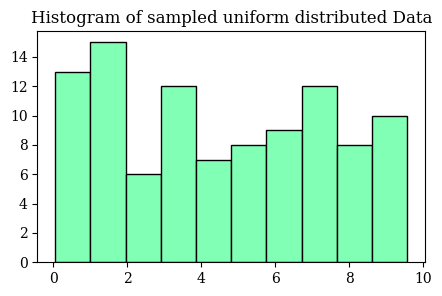

In [4]:
random_array=r.uniform(0, 9.7,100)

print("max:", random_array.max())

plt.hist(random_array, bins=10, density=False,color=my_cmap(0.5), edgecolor='black')
plt.title('Histogram of sampled uniform distributed Data')
plt.show()


# Save to file and read from file
df = pd.DataFrame(random_array)
df.columns = ['x']

df.to_csv('sampled_uniform_data.csv', index=False,sep=',')

df = pd.read_csv('sampled_uniform_data.csv')
df;

max: 1.364884667335197


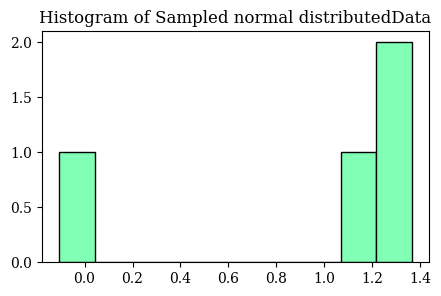

In [5]:
random_array=r.normal(1.30, np.sqrt(0.5), 4)
print("max:", random_array.max())

plt.hist(random_array, bins=10, density=False,color=my_cmap(0.5), edgecolor='black')
plt.title('Histogram of Sampled normal distributedData')
plt.show()



# Save to file and read from file
df = pd.DataFrame(random_array)
df.columns = ['x']

df.to_csv('sampled_normal_data_2_2.csv', index=False,sep=',')
df;

## Beginning with analysing


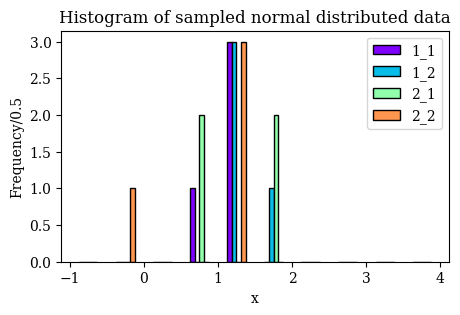

In [6]:
"""read from file"""
df1_1 = pd.read_csv('sampled_normal_data_1_1.csv')
df1_2 = pd.read_csv('sampled_normal_data_1_2.csv')
df2_1 = pd.read_csv('sampled_normal_data_2_1.csv') 
df2_2 = pd.read_csv('sampled_normal_data_2_2.csv')


"""plot histogram of sampled data"""
fig,ax=plt.subplots(1)
hist_min=-1
hist_max=4
N_bins=10
bin_width=(hist_max-hist_min)/N_bins

df_combined = [df1_1["x"], df1_2["x"], df2_1["x"], df2_2["x"]]
datasets=['1_1','1_2','2_1','2_2']
colors=my_cmap(np.linspace(0,0.8,len(datasets)))

ax.hist(df_combined[:], bins=N_bins, range=(hist_min, hist_max), density=False,histtype='bar', edgecolor='black',color=colors ,rwidth=0.5, label=datasets)
ax.legend()
ax.set_xlabel('x')
ax.set_ylabel(f'Frequency/{bin_width}')
ax.set_title('Histogram of sampled normal distributed data')

df_combined;

In [7]:
data_points=np.array([1.01,1.3,1.35,1.44])

mu=[1.25,1.30]
sigma=[np.sqrt(0.11), np.sqrt(0.5)]


#likelihood of above manually entered data_points for normal distribution, given mean and sigma
likelihood=1
for x in data_points:
    likelihood=stats.norm.pdf(x, loc=mu[0], scale=sigma[0])*likelihood
print(f'Likelihood of data given mean{mu[0]:5.2f} and sigma{sigma[0]:5.2f}: {likelihood:5.2f}')



likelihood=1
for x in data_points:
    likelihood=stats.norm.pdf(x, loc=mu[1], scale=sigma[1])*likelihood
print(f'Likelihood of data given mean{mu[1]:5.2f} and sigma{sigma[1]:5.2f}: {likelihood:5.2f}')

Likelihood of data given mean 1.25 and sigma 0.33:  1.29
Likelihood of data given mean 1.30 and sigma 0.71:  0.09


## Exercise 1

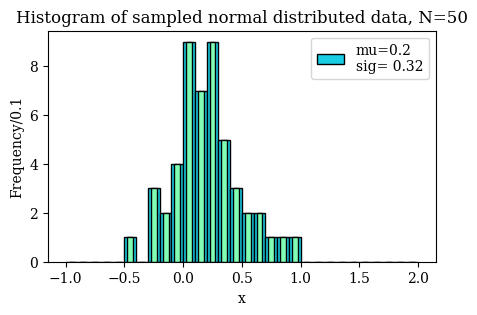

In [8]:
#given parameters
mu_given=0.2
sig_given=np.sqrt(0.1)


#generate normal data"""
random_array=r.normal(loc=mu_given, scale=sig_given, size=50)


#histogram of sampled data"""
fig,ax=plt.subplots(1)
hist_min=-1
hist_max=2
N_bins=30
bin_width=(hist_max-hist_min)/N_bins

ax.hist(random_array, bins=N_bins, range=(hist_min, hist_max), density=False,histtype='bar', edgecolor='black',color=my_cmap(0.3), label=f"mu={mu_given}\nsig={sig_given:5.2f}" )
ax.legend()
ax.set_xlabel('x')
ax.set_ylabel(f'Frequency/{bin_width}')
ax.set_title('Histogram of sampled normal distributed data, N=50')

#save to file"""
df = pd.DataFrame(random_array)
df.columns = ['x']
df.to_csv('sampled_normal_data_exc1.csv', index=False,sep=',')

#read from file"""
df_exc1 = pd.read_csv('sampled_normal_data_exc1.csv')

ax.hist(df_exc1['x'], bins=N_bins, range=(hist_min, hist_max), density=False,histtype='bar', edgecolor='black',color=my_cmap(0.5), label=f"mu={mu_given}\nsig={sig_given:5.2f}", rwidth=0.5);

In [9]:
#likelihood of data df_exc1 given mean and sigma for normal distribution"""
likelihood=1

for x in df_exc1['x']:
    likelihood=stats.norm.pdf(x, loc=mu_given, scale=sig_given)*likelihood

print(f'Likelihood of data given mean and sigma: {likelihood:.8f}')
print(f"mu given:{mu_given:5.2f}, sig_given:{sig_given:5.3f}")

calculated_mean=df_exc1['x'].mean()
calculated_sigma=df_exc1['x'].std()
print(f"calculated mean: {calculated_mean:5.2f}, calculated sigma: {calculated_sigma:5.2f}")

Likelihood of data given mean and sigma: 0.00013320
mu given: 0.20, sig_given:0.316
calculated mean:  0.21, calculated sigma:  0.29


In [10]:
#generate raster data of likelihood and llh
n_mu=20
n_sig=20
mu_min=0.1
mu_max=0.4
sig_min=0.2
sig_max=0.4

raster_array_likelihood=np.zeros([n_mu,n_sig])
raster_array_llh1=np.zeros([n_mu,n_sig])

for i_mu,mu in enumerate(np.linspace(mu_min, mu_max, n_mu)):
    for i_sig,sig in enumerate(np.linspace(sig_min, sig_max, n_sig)):
        
        likelihood=1
        llh1=0
        for x in df_exc1['x']:
            likelihood=stats.norm.pdf(x, loc=mu, scale=sig)*likelihood
            llh1=-np.log(stats.norm.pdf(x, loc=mu, scale=sig))+llh1

        raster_array_likelihood[i_mu,i_sig]=likelihood
        raster_array_llh1[i_mu,i_sig]=llh1

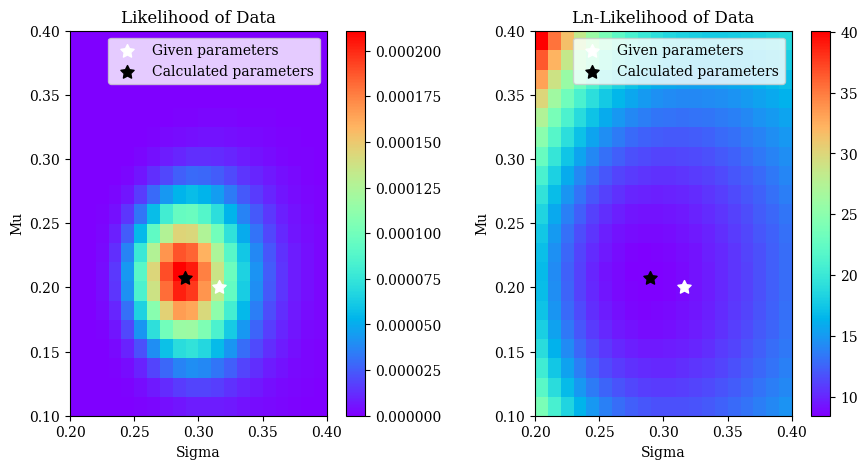

In [11]:
#draw raster plot
fig, ax = plt.subplots(1,2,figsize=(11, 5))
im0=ax[0].imshow(raster_array_likelihood, cmap=my_cmap,  aspect=None, extent=(sig_min, sig_max,mu_min, mu_max), origin='lower')
ax[0].scatter(sig_given,mu_given, color='white', marker=(5, 1), s=100, label='Given parameters')
ax[0].scatter(calculated_sigma, calculated_mean, color='black', marker=(5, 1), s=100, label='Calculated parameters')
ax[0].set_ylabel('Mu')
ax[0].set_xlabel('Sigma')
ax[0].set_title('Likelihood of Data')
ax[0].legend()

im1=ax[1].imshow(raster_array_llh1, cmap=my_cmap,  aspect=None, extent=(sig_min, sig_max,mu_min, mu_max), origin='lower')
ax[1].scatter(sig_given,mu_given, color='white', marker=(5, 1), s=100, label='Given parameters')
ax[1].scatter(calculated_sigma, calculated_mean, color='black', marker=(5, 1), s=100, label='Calculated parameters')
ax[1].set_ylabel('Mu')
ax[1].set_xlabel('Sigma')
ax[1].set_title('Ln-Likelihood of Data')
ax[1].legend()


cbar = ax[0].figure.colorbar(im0, ax=ax[0])#, **cbar_kw)
cbar = ax[1].figure.colorbar(im1, ax=ax[1])

In [12]:
def neg_ln_likelihood(array,a,b):
    llh=0
    for x in array:
        llh=-stats.norm.logpdf(x, loc=a, scale=b)+llh
    return llh

In [13]:
print("maximum likelihood:", raster_array_likelihood.max())
print("minimum llh in raster:", raster_array_llh1.min())

true_llh=neg_ln_likelihood(df_exc1['x'], mu_given, sig_given)
print("true llh from given parameters:", true_llh)

calc_llh=neg_ln_likelihood(df_exc1['x'], calculated_mean, calculated_sigma)
print("calculated llh from data:", calc_llh)

maximum likelihood: 0.00021097787197979034
minimum llh in raster: 8.46375730212137
true llh from given parameters: 8.923639566376774
calculated llh from data: 8.461561260272111


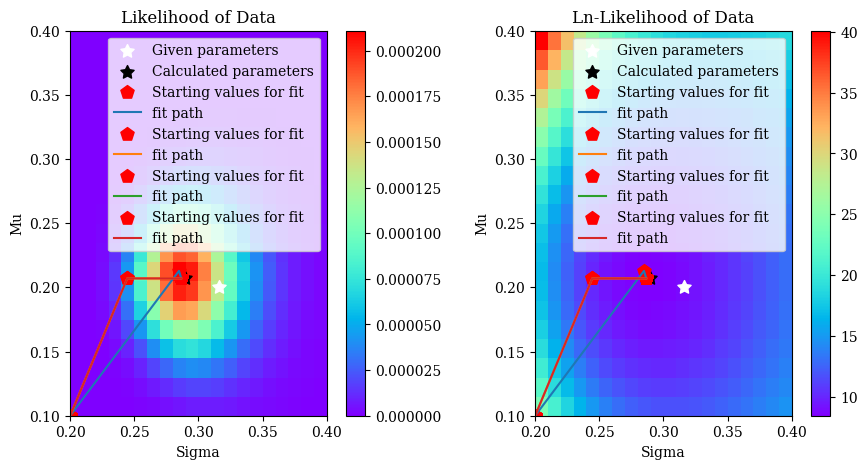

In [ ]:
#define starting values for fit parameters a and b, and perform fit using Minuit
mu_fit_array=[mu_min]
sig_fit_array=[sig_min]

for i in range(20):


    mfit = Minuit(lambda a, b: neg_ln_likelihood(df_exc1["x"], a, b), a=mu_fit_array[i], b=sig_fit_array[i])
    #mfit.scan(ncall=50)
    mfit.migrad(ncall=10)

    mu_fit_array.append(mfit.values['a'])
    sig_fit_array.append(mfit.values['b'])
    #print(f"mu={mu_fit_array[-1]:10.5f}, sig={sig_fit_array[-1]:10.5f}")


ax[0].scatter(sig_fit_array, mu_fit_array, color='red', marker=(5, 0), s=100, label='Starting values for fit')
ax[0].plot(sig_fit_array, mu_fit_array, label='fit path')
ax[0].legend()

ax[1].scatter(sig_fit_array, mu_fit_array, color='red', marker=(5, 0), s=100, label='Starting values for fit')
ax[1].plot(sig_fit_array, mu_fit_array, label='fit path')
ax[1].legend()

fig
#mfit.migrad()


#pts=mfit.draw_mncontour("a", "b", cl=0.68 ,size=20,experimental=True);
#x4, y4 = np.transpose(pts)


#ax[0].plot(x4, y4, "-", label="size=50 experimental")
